# Pipelines: writing less of the same thing

Most analysis scripts open the same way. A `getinfo`, then one getter per component, each
repeating the selection you already decided on:

```julia
info = getinfo(300, path)
gas  = gethydro(info,     lmax=10, xrange=[-10., 10.], center=[:bc], range_unit=:kpc)
grav = getgravity(info,   lmax=10, xrange=[-10., 10.], center=[:bc], range_unit=:kpc)
part = getparticles(info, lmax=10, xrange=[-10., 10.], center=[:bc], range_unit=:kpc)
```

Nothing there is wrong, but three quarters of it is repetition, and repetition is where a
selection quietly drifts between components. Mera gives you two independent ways to remove
it, and they compose.

## One bundle for the selection

[`ArgumentsType`](@ref), usually written `myargs`, holds the selection once and travels with
you. It is covered in full on [Bundled Arguments](bundled_arguments.md); the short version:

```julia
args = ArgumentsType(lmax=10, xrange=[-10., 10.], yrange=[-10., 10.],
                     center=[:bc], range_unit=:kpc)

gas  = gethydro(info,   myargs=args)
proj = projection(gas, :sd, myargs=args)     # the same bundle, further down the pipeline
```

Change the region once and every step follows. Nothing can drift, because there is only one
copy of the numbers.

When you need a variant, [`withargs`](@ref) derives one and leaves the original alone:

```julia
coarse = withargs(args; lmax=7)                      # same region, fewer levels
zoom   = withargs(args; xrange=[-2., 2.], yrange=[-2., 2.])
```

Without it that is a `deepcopy` and an assignment, with the original one slip away from
being edited in place.

In [1]:
using Mera, CairoMakie
CairoMakie.activate!()

# This page runs on mw_L10 output 300, a 48 kpc Milky-Way box with 640 CPU files.
# Point MW at any RAMSES output or converted MERA file of your own: every step below
# works the same either way.
MW = get(ENV, "MERA_MW", "/Volumes/FASTStorage/Simulations/Mera-Tests/RAMSES/mw_L10")

# the selection, written once
args = ArgumentsType(lmax=9,
                     xrange=[-12., 12.], yrange=[-12., 12.], zrange=[-2., 2.],
                     center=[:bc], range_unit=:kpc)

# a variant, without touching the original
zoom = withargs(args; xrange=[-4., 4.], yrange=[-4., 4.])
(args.xrange, zoom.xrange)


*__   __ _______ ______   _______ 


|  |_|  |       |    _ | |   _   |
|       |    ___|   | || |  |_|  |
|       |   |___|   |_||_|       |
|       |    ___|    __  |       |
| ||_|| |   |___|   |  | |   _   |
|_|   |_|_______|___|  |_|__| |__|
Mera v1.8.0 | Julia 1.12.7 | 8 threads



([-12.0, 12.0], [-4.0, 4.0])

## One call for the loading

[`loadall`](@ref) does the other half: `getinfo` and every getter in a single call, returning
the components named.

```julia
(; hydro, gravity, particles) = loadall(path, 300; myargs=args)
```

That is the four lines above. The names on the left are ordinary variables you wrote, so a
reader can see where each came from, and every tool that reads Julia can follow them.

It returns a `NamedTuple`, so `info` comes back too and nothing is lost:

```julia
d = loadall(path, 300; myargs=args)
d.info.levelmax
d.hydro
```

By default it reads **every component the snapshot has**. A run without gravity returns
fewer fields rather than failing, so the same line works across simulations that do not hold
the same things:

```julia
d = loadall(path, 300)
keys(d)          # (:hydro, :gravity, :particles, :info), or fewer
```

**All six readers are covered**, not just the three above. Clump catalogues, sink particles
and radiative-transfer data come back the same way, and each reader is only attempted when
`info` says the snapshot holds it:

| component | reader |
|---|---|
| `:hydro`, `:gravity`, `:particles` | `gethydro`, `getgravity`, `getparticles` |
| `:clumps`, `:sinks`, `:rt` | `getclumps`, `getsinks`, `getrt` |

The keywords you pass are forwarded only to the readers that accept them. `getsinks`, for
instance, takes no `myargs`, and a sink catalogue has no spatial selection to apply anyway;
passing a bundle for the other components does not disturb it. If a component does fail to
read you get a warning and `nothing` in that field, never a silent gap.

### The same call on a converted snapshot

`loadall` looks for `output_NNNNN.jld2` in the folder and dispatches accordingly:

| | RAMSES output | converted MERA file |
|---|---|---|
| metadata | `getinfo` | `infodata` |
| components | `gethydro`, `getgravity`, … | `loaddata` |

You call neither directly, and **the call does not change**, so converting your data does
not mean rewriting your scripts:

```julia
(; hydro, gravity, particles) = loadall("/path/to/ramses",    300)   # RAMSES output
(; hydro, gravity, particles) = loadall("/path/to/merafiles", 300)   # converted, same line
```

Selection works on both. Measured on a 28.3M-cell snapshot, taking a 10 x 10 x 4 kpc slab
out of a MERA file:

```julia
d = loadall(merapath, 300; components=(:hydro,),
            xrange=[-5., 5.], yrange=[-5., 5.], zrange=[-2., 2.],
            center=[:bc], range_unit=:kpc)
# 2,777,683 cells of 28,320,979
```

The macros work the same way on both, and so do bundles:

```julia
args = ArgumentsType(xrange=[-4., 4.], yrange=[-4., 4.], zrange=[-1., 1.],
                     center=[:bc], range_unit=:kpc)

@loadall merapath 300 hydro gravity myargs=args
@project hydro sd=>:Msol_pc2 T=>:K
```

`info` comes back in the `NamedTuple` either way, so you never need to decide whether to
call `getinfo` or `infodata` yourself.

### Two differences to know about

**The spatial selection costs differently.** On a RAMSES output it is applied while reading,
so the rest is never touched. A MERA file is read whole and then cut. See
[Performance](benchmarks/performance.md) for why, and for when to save the subregion as its
own file instead.

**`lmax` does not apply to a MERA file.** A converted file holds the levels it was written
with, and `loaddata` has no level cap, so every stored level comes back. The same bundle
therefore gives different cell counts on the two routes. Measured on `mw_L10` output 300, a
24 x 24 x 4 kpc slab with `lmax=9`:

| | cells | gas mass |
|---|---:|---:|
| RAMSES output | 2,761,245 | 6.786e9 M⊙ |
| MERA file | 8,329,355 | 6.786e9 M⊙ |

The **mass is identical**, because capping the level coarsens cells without losing any of
them; only the cell count differs. `loadall` warns when you pass `lmax` on the MERA-file
route rather than quietly returning something else than you asked for. If you want a coarser
file, apply the cap when you convert.

Ask for a subset by name, with or without a bundle:

```julia
loadall(path, 300; components=(:hydro, :particles), myargs=args)
loadall(path, 300; components=(:hydro,), lmax=9)      # keywords work inline too
```

In [2]:
# getinfo and every getter in one call, honouring the bundle
(; hydro, particles, info) = loadall(MW, 300; components=(:hydro, :particles), myargs=args)

(cells = length(hydro.data), particles = length(particles.data), levelmax = info.levelmax)

loadall: output 300 (RAMSES output

), components: hydro, particles


Processing files:   0%|                                                  |  ETA: N/A (  N/A  s/it)

Processing files:   3%|█▍                                                |  ETA: 0:00:38 (60.79 ms/it)

Processing files:   4%|██                                                |  ETA: 0:00:35 (56.30 ms/it)

...

Processing files:  99%|█████████████████████████████████████████████████▎|  ETA: 0:00:00 (27.51 ms/it)

Processing files: 100%|██████████████████████████████████████████████████| Time: 0:00:17 (27.54 ms/it)



✓ File processing complete! Combining results...


┌ Warning: getparticles: the `lmax` level cap is not yet supported for particles; loading the full level range (lmax=10). The `lmax` argument is currently ignored.
└ @ Mera ~/code-github/Mera.jl/src/read_data/RAMSES/getparticles.jl:246


(cells = 2761245, particles = 541797, levelmax = 10)

In [3]:
# a number from the same region
msum(hydro, :Msol)

6.7859604858483305e9

### More than gas, gravity and stars

Most snapshots hold hydro, gravity and particles, which is why the examples name those.
Nothing is limited to them. Ask for clumps, sinks or radiative transfer by name, in the
function or in the macro:

```julia
(; hydro, rt)     = loadall(path, 7;   components=(:hydro, :rt))
(; clumps, sinks) = loadall(path, 300; components=(:clumps, :sinks))

@loadall path 7 hydro rt          # the macro takes them too
@loadall path 300 hydro clumps sinks
```

Left to itself `loadall` reads whatever `info` reports, so **one line covers snapshots that
hold different things**. Three public test simulations, the same call on each:


In [4]:
# three small public fixtures, each carrying something different
for (name, out) in (("stromgren3d", 7), ("clumps3d", 4), ("sinks3d", 2))
    path = download_testdata(name, verbose=false)
    d    = loadall(path, out, verbose=false, show_progress=false)
    println("$(rpad(name, 14)) output $out  ->  $(keys(d))")
end


stromgren3d    output 7  ->  (:hydro, :rt, :info)


clumps3d       output 4  ->  (:hydro, :gravity, :clumps, :info)


sinks3d        output 2  ->  (:hydro, :gravity, :particles, :sinks, :info)


## The macro, and when not to reach for it

[`@loadall`](@ref) is a thin wrapper that expands to exactly the destructuring above:

```julia
@loadall path 300 hydro gravity particles
```

It binds `hydro`, `gravity`, `particles` and `info` in your scope. That is a normal thing
for a Julia macro to do, in the same family as `@unpack`, `@variables` and `@parameters`,
and it is fine in scripts and notebooks alike: the line that produced the names is right
there above them.

Bundles work here too, so the macro loses nothing:

```julia
@loadall path 300 hydro gravity myargs=args
@loadall path 300 hydro particles lmax=10 range_unit=:kpc
@loadall path 300 hydro rt clumps sinks
```

The macro creates the variables as it expands, so there is no assignment to `hydro` or
`gravity` written anywhere in your file. In a script or a notebook that reads fine: the
`@loadall` line sits right above and names everything it creates.

**Inside a longer function, or in package code, prefer the explicit form.** Someone reading
it sees where `hydro` came from on the line itself, and editors, linters and "go to
definition" can follow a plain assignment, which they cannot always do through a macro. It
costs a few characters:

```julia
(; hydro, gravity, particles) = loadall(path, 300; myargs=args)
```

Both forms call the same function and return the same objects; pick whichever reads better
where you are.

In [5]:
# the macro form binds the names directly
@loadall MW 300 hydro myargs=args
length(hydro.data)

loadall: output 300 (RAMSES output), components: hydro


Processing files:   0%|                                                  |  ETA: N/A (  N/A  s/it)

Processing files:   1%|▎                                                 |  ETA: 0:00:52 (81.28 ms/it)

Processing files:   1%|▊                                                 |  ETA: 0:00:30 (47.51 ms/it)

Processing files:   2%|█▏                                                |  ETA: 0:00:28 (44.70 ms/it)

...

Processing files:  99%|█████████████████████████████████████████████████▋|  ETA: 0:00:00 (33.33 ms/it)

Processing files:  99%|█████████████████████████████████████████████████▊|  ETA: 0:00:00 (33.46 ms/it)

Processing files: 100%|██████████████████████████████████████████████████| Time: 0:00:21 (33.46 ms/it)



✓ File processing complete! Combining results...


2761245

## One call for the projection

`projection` returns a single object whose `maps` is a dictionary, so pulling several
quantities out of it is a line of lookups:

```julia
pj = projection(gas, [:sd, :T], myargs=args)
sd = pj.maps[:sd]; T = pj.maps[:T]
```

[`@project`](@ref) does that in one line, and asking for the quantities together is also the
form that lets the projection use its threads, see
[Performance](benchmarks/performance.md):

```julia
@project gas sd T myargs=args
```

`sd` and `T` are now the maps, and `proj` is the full object, so the extent and everything
else stay reachable:

```julia
heatmap(proj.extent[1:2], proj.extent[3:4], sd)
```

Units go with the quantity they belong to, so adding a third cannot silently misalign a
positional list:

```julia
@project gas sd=>:Msol_pc2 T=>:K myargs=args
@project gas sd=>:Msol_pc2 T                  # anything without a unit stays :standard
```

Keywords pass straight through, so **off-axis needs no separate macro**, and neither does
anything else `projection` accepts:

```julia
@project gas sd inclination=60 azimuth=30 binning=:exact
@project gas sd pxsize=[100., :pc] direction=:x
@project gas sd mask=my_mask xrange=[-5., 5.] center=[:bc] range_unit=:kpc
```

!!! note "One limit worth knowing"
    Every `keyword=value` you write is handed straight to the underlying function, so any
    keyword the getters or `projection` accept works here too, including ones added later.

    What a macro cannot take is a ready-made collection of keywords. Use the function for
    that:

    ```julia
    projection(gas, [:sd]; kws...)
    ```

    The macro says so if you try. A test checks that each macro gives the same result as
    the call it stands for.

In [6]:
# maps in physical units, bound to names; `proj` carries the extent and the rest
@project hydro sd=>:Msol_pc2 T=>:K myargs=args

(sd = size(sd), T = size(T), extent_kpc = round.(proj.extent, digits=1))

[Mera]: 2026-09-09T17:33:44.255



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.25 :: 0.75  	==> 12.0 [kpc] :: 36.0 [kpc]
ymin::ymax: 0.25 :: 0.75  	==> 12.0 [kpc] :: 36.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd, :T) 
Weighting      = :mass

Effective resolution: 512^2
Map size: 256 x 256
Pixel size: 93.75 [pc]
Simulation min.: 93.75 [pc]

Available threads: 8


Requested max_threads: 8
Variables: 2 (T, sd)
Processing mode: Variable-based parallel (2 threads)


(sd = (256, 256), T = (256, 256), extent_kpc = [12.0, 36.0, 12.0, 36.0])

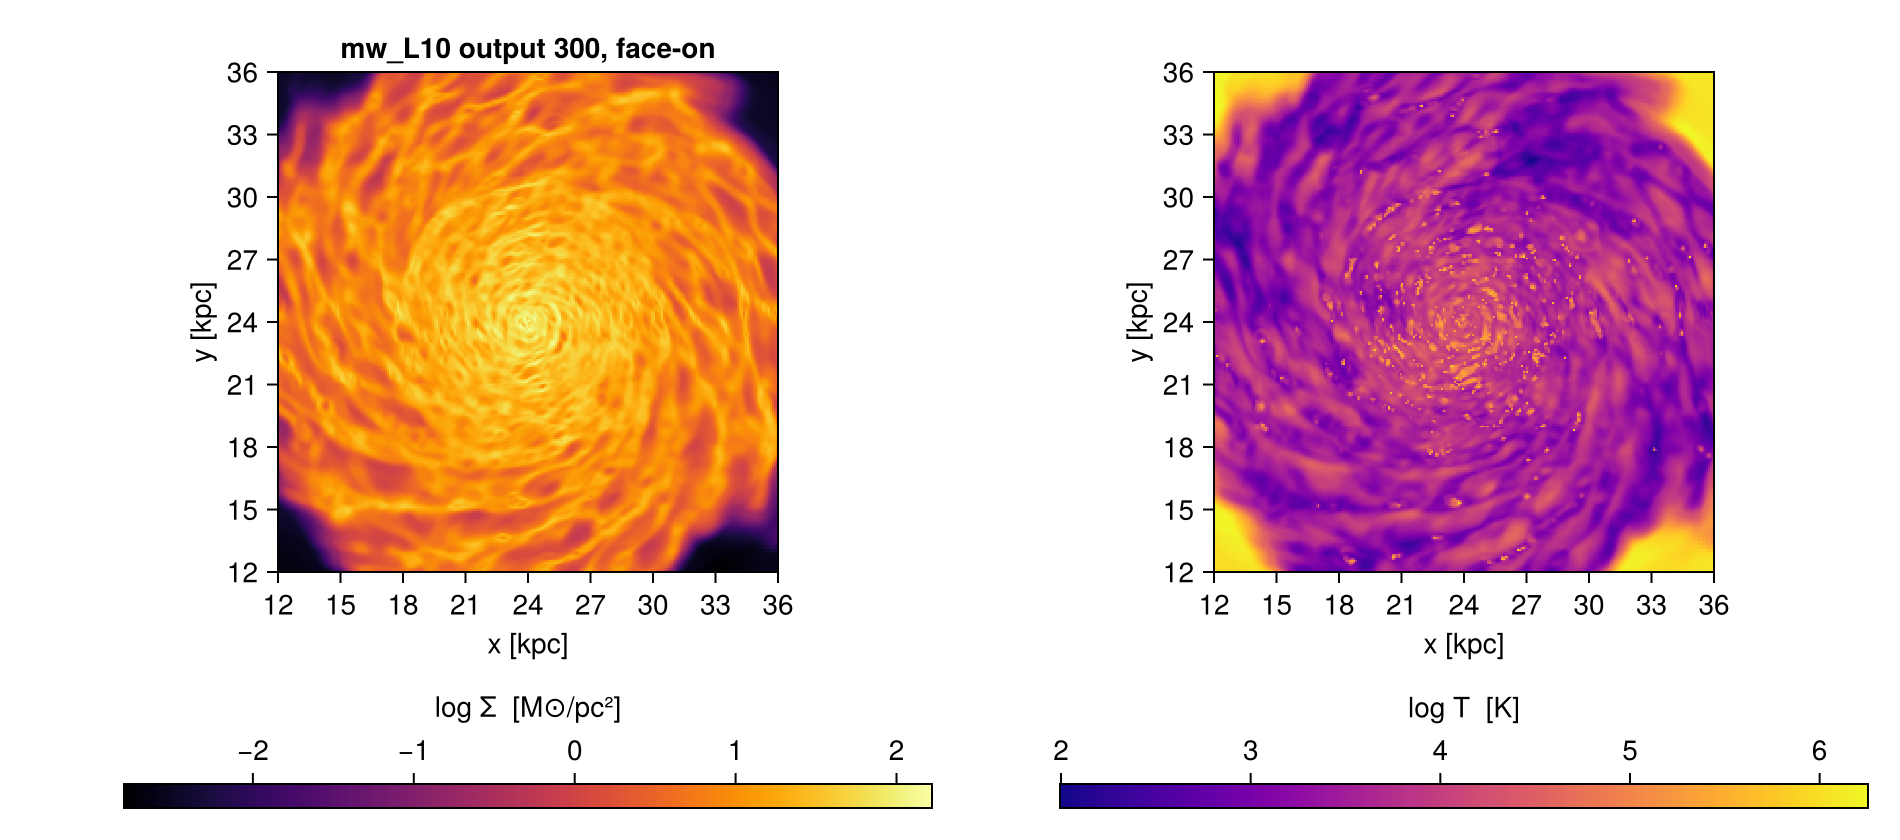

In [7]:
fig = Figure(size=(950, 420))
for (i, (m, lab, cm)) in enumerate(((sd, "log Σ  [M⊙/pc²]", :inferno),
                                    (T,  "log T  [K]",      :plasma)))
    ax = Axis(fig[1, i], aspect=DataAspect(), xlabel="x [kpc]", ylabel="y [kpc]",
              title = i == 1 ? "mw_L10 output 300, face-on" : "")
    hm = heatmap!(ax, proj.extent[1:2], proj.extent[3:4], log10.(max.(m, eps())); colormap=cm)
    Colorbar(fig[2, i], hm, label=lab, vertical=false)
end
fig

In [8]:
# off-axis needs no separate macro: the keywords pass straight through
@project hydro sd=>:Msol_pc2 inclination=60 azimuth=30 myargs=args
size(sd)

[Mera]: 2026-09-09T17:33:58.540



center: [0.5, 0.5, 0.5] ==> [24.0 [kpc] :: 24.0 [kpc] :: 24.0 [kpc]]

domain:
xmin::xmax: 0.25 :: 0.75  	==> 12.0 [kpc] :: 36.0 [kpc]
ymin::ymax: 0.25 :: 0.75  	==> 12.0 [kpc] :: 36.0 [kpc]
zmin::zmax: 0.4583333 :: 0.5416667  	==> 22.0 [kpc] :: 26.0 [kpc]

Selected var(s)=(:sd,) 


Weighting      = :mass
Off-axis LOS   = 

[0.433, -0.75, 0.5]  (binning=:overlap)
Effective resolution: 512^2  →  map size: 353 x 215



(353, 215)

## A whole opening, in three lines

```julia
args = ArgumentsType(lmax=10, xrange=[-10., 10.], yrange=[-10., 10.],
                     center=[:bc], range_unit=:kpc)
(; hydro, particles) = loadall(path, 300; components=(:hydro, :particles), myargs=args)
@project hydro sd T myargs=args
```

The selection appears once, the loading appears once, and the projection reuses both. Three
lines that in full would be a `getinfo`, two getters repeating the same six keywords, a
`projection` repeating them again, and two dictionary lookups.

## Selecting inside the table

Two more macros work on a loaded object rather than on the loading. They are documented with
the features they belong to, and listed here so the pipeline story is in one place:

| | |
|---|---|
| [`@filter`](@ref), [`@where`](@ref), [`@apply`](@ref) | value-based selection on the table, see [Masking and Filtering](05_multi_Masking_Filtering.md) |
| [`@region`](@ref) | compose geometric regions, see [Get Subregions](03_hydro_Get_Subregions.md) |

## A complete workflow

From a path to a figure and a number, with every tool on this page doing its part.

```julia
using Mera, CairoMakie

path = "/path/to/simulation"

# 1. the selection, written once
args = ArgumentsType(lmax=10,
                     xrange=[-15., 15.], yrange=[-15., 15.], zrange=[-3., 3.],
                     center=[:bc], range_unit=:kpc)

# 2. everything the snapshot has, in one call, honouring that selection
(; hydro, particles, info) = loadall(path, 300; myargs=args)

# 3. a number: total gas mass in the region
mass = msum(hydro, :Msol)
println("gas mass in the slab: ", round(mass, sigdigits=4), " Msol")

# 4. maps in physical units, bound to names
@project hydro sd=>:Msol_pc2 T=>:K myargs=args

# 5. a figure, using the extent the projection recorded
fig = Figure(size=(900, 380))
for (i, (m, label)) in enumerate(((sd, "Σ [M⊙/pc²]"), (T, "T [K]")))
    ax = Axis(fig[1, i], aspect=DataAspect(), xlabel="x [kpc]", ylabel="y [kpc]")
    hm = heatmap!(ax, proj.extent[1:2], proj.extent[3:4], log10.(m); colormap=:inferno)
    Colorbar(fig[2, i], hm, label="log10 " * label, vertical=false)
end
fig
```

Two things worth noticing. `args` is written once and reaches the loading **and** the
projection, so the map and the mass describe the same region by construction. And `proj`
carries the extent, so the axes are in kpc without you tracking the conversion yourself.

To narrow the region without touching the original bundle:

```julia
zoom = withargs(args; xrange=[-3., 3.], yrange=[-3., 3.])
(; hydro) = loadall(path, 300; components=(:hydro,), myargs=zoom)
@project hydro sd=>:Msol_pc2 myargs=zoom
```

And the same, in the explicit form, for a script or a package:

```julia
d    = loadall(path, 300; myargs=args)
proj = projection(d.hydro, [:sd, :T], [:Msol_pc2, :K], myargs=args)
sd, T = proj.maps[:sd], proj.maps[:T]
```

## See also

- [Bundled Arguments](bundled_arguments.md), `myargs` in depth
- [Load by Selection](02_hydro_Load_Selections.md), what the selection keywords mean
- [Multi-threading](multi-threading/multi-threading_intro.md), for reading several snapshots at once